# 00 — Setup & Sanity Checks (Run This First)

**Intention**: This notebook is a *single place* to verify that your environment is ready for the course notebooks.

It checks:
- Your selected Python kernel is the one you expect
- `inventory` (and optionally `queueing`) imports work
- strict-CRN evaluation is *deterministic* when `(seed0, n_episodes, T, S0, eval_info)` are held fixed
- Repo conventions reference: [concepts/00_repo_conventions.ipynb](../concepts/00_repo_conventions.ipynb)

If something fails here, it will also fail later — but here it’s easier to debug.

---

## What “good” looks like
- All cells run without exceptions.
- The strict-CRN determinism cell prints `same=True`.
- (Optional) The plotting cell shows a simple histogram+boxplot figure.

In [1]:
import sys
import platform

print('python:', sys.version)
print('executable:', sys.executable)
print('platform:', platform.platform())

python: 3.12.7 (main, Oct  1 2024, 02:05:46) [Clang 15.0.0 (clang-1500.3.9.4)]
executable: /Users/christopherlisson/Projects/sdam_introduction/.venv/bin/python
platform: macOS-26.3-arm64-arm-64bit


In [2]:
# Import smoke tests
import numpy as np

import inventory
print('inventory imported from:', inventory.__file__)

try:
    import queueing
    print('queueing imported from:', queueing.__file__)
except Exception as e:
    print('queueing import: skipped/failed (ok if not needed yet):', type(e).__name__, e)

inventory imported from: /Users/christopherlisson/Projects/sdam_introduction/lectures/inventory/__init__.py
queueing imported from: /Users/christopherlisson/Projects/sdam_introduction/lectures/queueing/__init__.py


## Optional: scenarios runner smoke check

This verifies the queueing `scenarios` package imports and that the canonical runner entrypoint works.

We run just Scenario 01 in `--fast` mode to keep it quick.

In [2]:
import contextlib
import io
import os

import scenarios

print("scenarios imported from:", scenarios.__file__)

from scenarios.run_all import main as run_scenarios_main

# Run only Scenario 01 in fast mode (should be quick)
_old_fast = os.environ.get("SDAM_FAST")
_buf = io.StringIO()
try:
    with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
        exit_code = run_scenarios_main(["--fast", "--only", "scenarios.scenario_01_mm1", "--no-env"])
finally:
    if _old_fast is None:
        os.environ.pop("SDAM_FAST", None)
    else:
        os.environ["SDAM_FAST"] = _old_fast

_out_lines = _buf.getvalue().splitlines()
print("scenarios runner exit_code:", exit_code)
print("scenarios runner output (first 20 lines):")
print("\n".join(_out_lines[:20]))
if len(_out_lines) > 20:
    print(f"... ({len(_out_lines) - 20} more lines suppressed)")

print("Terminal equivalent:")
print("  poetry run sdam-scenarios --fast --only scenarios.scenario_01_mm1 --no-env")


scenarios imported from: /Users/christopherlisson/Projects/sdam_introduction/src/scenarios/__init__.py
scenarios runner exit_code: 0
scenarios runner output (first 20 lines):

=== Running all scenarios ===
DES seed=0 | CRN seed0=0


Scenario 01 — M/M/1 basics

## Strict-CRN Monte Carlo policy evaluation (Queueing Networks)
n_rep=3  seed0=0  T=200.0  overflow=block
baseline='Baseline'

### Metric: throughput (higher=better)
  -           Baseline: mean=0.818333  std=0.069342
  -          Baseline2: mean=0.818333  std=0.069342
    Δ(Baseline2-Baseline): mean=0.000000  std=0.000000  win_rate=0.000

### Metric: mean_cycle_time (lower=better)
  -           Baseline: mean=5.294632  std=2.439210
... (30 more lines suppressed)
Terminal equivalent:
  poetry run sdam-scenarios --fast --only scenarios.scenario_01_mm1 --no-env


## Strict-CRN determinism (inventory)

This is a *core promise* in the lectures: when we compare policies under strict CRN, the Monte Carlo noise is reduced and repeated runs with the same seed settings are reproducible.

We run `evaluate_policies_crn_mc(...)` twice with identical inputs and verify the totals arrays match exactly.

In [3]:
import numpy as np

from inventory.core.dynamics import DynamicSystemMVP
from inventory.evaluation import make_eval_info
from inventory.policies.baselines import OrderUpToPolicy
from inventory.problems.demand_models import PoissonConstantDemand
from inventory.problems.inventory_mvp import inventory_cost_extended, inventory_transition

# Small, fast instance (keep this lightweight)
T = 12
S0 = np.array([80.0], dtype=float)
seed0 = 1234
n_episodes = 50

# Exogenous demand model
exo = PoissonConstantDemand(lam=60)

# Costs (lower is better)
p, c, h, b, K = 2.0, 0.5, 0.03, 1.0, 50.0
transition_func = inventory_transition
cost_func = lambda s, a, w, t: inventory_cost_extended(s, a, w, t, p=p, c=c, h=h, b=b, K=K)

system = DynamicSystemMVP(
    transition_func=transition_func,
    cost_func=cost_func,
    exogenous_model=exo,
    sim_seed=42,
    d_s=1,
    d_x=1,
    d_w=1,
 )

policies = {
    "baseline": OrderUpToPolicy(target_level=120.0, x_max=480.0, dx=10),
    "candidate": OrderUpToPolicy(target_level=140.0, x_max=480.0, dx=10),
}

eval_info = make_eval_info(T=T, det_mode="argmax")

r1, _ = system.evaluate_policies_crn_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_episodes,
    seed0=seed0,
    info=eval_info,
 )
r2, _ = system.evaluate_policies_crn_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_episodes,
    seed0=seed0,
    info=eval_info,
 )

t1 = {k: np.asarray(v.totals, dtype=float) for k, v in r1.items()}
t2 = {k: np.asarray(v.totals, dtype=float) for k, v in r2.items()}

same = all(np.array_equal(t1[k], t2[k]) for k in t1.keys())
print("strict-CRN determinism: same=", same)
if not same:
    for k in t1.keys():
        mx = float(np.max(np.abs(t1[k] - t2[k])))
        print("  policy:", k, "max_abs_diff:", mx)

# Keep one totals mapping around for the plotting sanity check below
totals_by_policy = t1

strict-CRN determinism: same= True


## Optional: plotting sanity check

If matplotlib is available, we plot totals to confirm plotting works in your kernel.

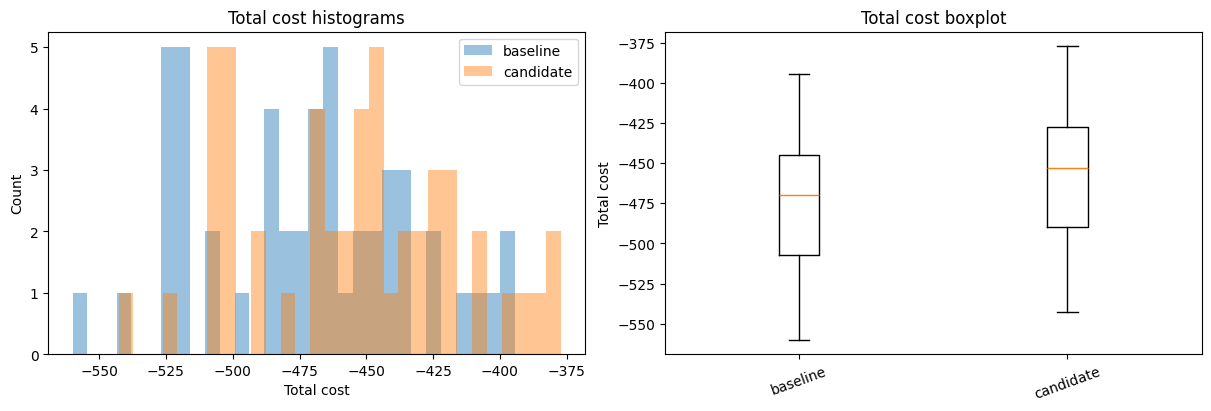

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Total cost histograms'}, xlabel='Total cost', ylabel='Count'>,
        <Axes: title={'center': 'Total cost boxplot'}, ylabel='Total cost'>],
       dtype=object))

In [4]:
from inventory.evaluation.plotting import plot_totals_hist_and_box

plot_totals_hist_and_box(totals_by_policy)

## Optional: pipeline import check

This checks the student-facing one-call helper imports cleanly.

In [5]:
from inventory.evaluation.notebooks.pipeline import CRNExperimentPipelineConfig

cfg = CRNExperimentPipelineConfig.fast()
cfg

CRNExperimentPipelineConfig(baseline_name='baseline', candidate_name='candidate', higher_is_better=False, show_step_headings=True, plot_totals=True, plot_reference_episode=True, reference_figsize=(12, 14), plot_overlay_rollouts=False, overlay_n_episodes=50, overlay_seed0=1234, overlay_figsize=(12, 14), overlay_alpha_episode=0.12, overlay_linewidth_episode=1.0, overlay_linewidth_mean=2.8, print_paired_delta_summary=True, print_candidate_report=True, compute_deltas=True, run_normality=False, run_frequentist=True, frequentist_random_state=0, run_bayesian=True, bayes_better=None, bayes_random_state=0, bayes_draws=50000, bayes_cred_level=0.95, bayes_delta=0.0, bayes_rope=0.0, bayes_mode='full')